In [3]:
pip install gymnasium matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install "gymnasium[classic-control]

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ----------------- ---------------------- 4.2/9.8 MB 25.3 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.8 MB 26.3 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 24.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

 
Análisis de los resultados obtenidos tras el entrenamiento
 
En la generación 0, el fitness medio es 5.8. El fitness del mejor individuo es 13.3, el cual tiene 0 nodos ocultos.
En la generación 10, el fitness medio es 10.8. El fitness del mejor individuo es 26.3, el cual tiene 0 nodos ocultos.
En la generación 20, el fitness medio es 12.6. El fitness del mejor individuo es 29.7, el cual tiene 0 nodos ocultos.
En la generación 30, el fitness medio es 14.1. El fitness del mejor individuo es 58.3, el cual tiene 2 nodos ocultos.
En la generación 40, el fitness medio es 14.8. El fitness del mejor individuo es 42.3, el cual tiene 2 nodos ocultos.
En la generación 50, el fitness medio es 13.5. El fitness del mejor individuo es 38.7, el cual tiene 2 nodos ocultos.
En la generación 60, el fitness medio es 18.7. El fitness del mejor individuo es 134.0, el cual tiene 3 nodos ocultos.
El problema se ha resuelto en la generacion 61
 
El fitness del mejor individuo es 1000.0
Tiene 15 nodos y 19 co

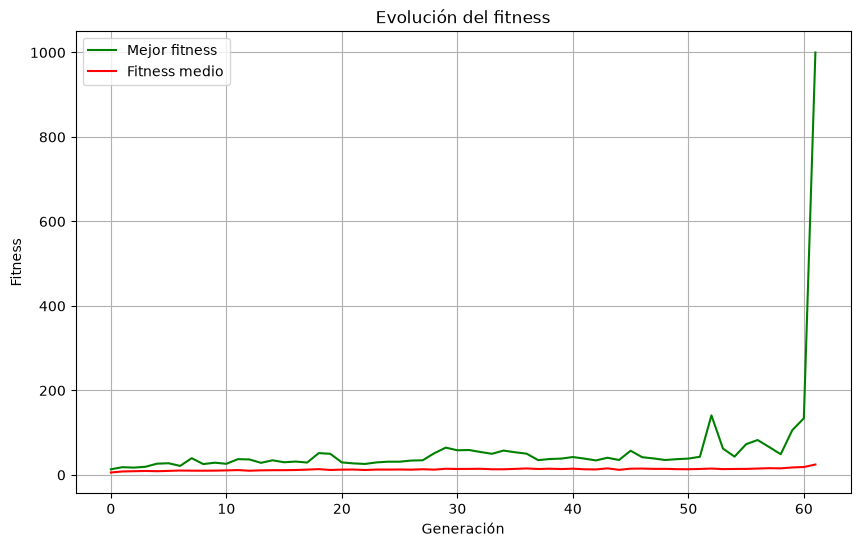

In [8]:
import math
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from NEAT1 import Genotipo, Poblacion

class DoblePenduloInvertidoGenotipo(Genotipo):
    
    def __init__(self, num_entradas=None, num_salidas=1):
        super().__init__()
        self.num_entradas = num_entradas
        self.num_salidas = num_salidas
        self.fitness = 0.0
    
    def inicializar(self, num_entradas, num_salidas=1):
        self.num_entradas = num_entradas
        self.num_salidas = num_salidas
        return self
    
    def decision(self, observacion):
        salida = self.fenotipo(observacion)
        accion_continua = (salida[0] - 0.5) * 2.0  # Al ser la función de activación sigmoidal, se debe mapear la salida de [0,1] a [-1,1]
        return np.array([accion_continua])
    
    def evaluar(self, entorno, max_pasos=1000, render=False):
        observacion, _ = entorno.reset()  #se reinicia el entorno
        recompensa_acumulada = 0  
        for _ in range(max_pasos):
            accion = self.decision(observacion)
            observacion, _ , fracaso, maximo, _ = entorno.step(accion)  #se ejecuta la accion
            recompensa_acumulada += 1
            if fracaso or maximo:
                break
        self.fitness = recompensa_acumulada
        return self.fitness
    
    def calcular_fitness(self, n_evaluaciones=3):
        entorno = gym.make("InvertedDoublePendulum-v4")
        fitness_total = 0
        for _ in range(n_evaluaciones):
            fitness_total += self.evaluar(entorno, max_pasos=1000)
        entorno.close()
        self.fitness = fitness_total / n_evaluaciones
        return self.fitness

def poblacion_inicial(poblacion, num_entradas=11, num_salidas=1):
    for i in poblacion.individuos:
        i.num_entradas = num_entradas
        i.num_salidas = num_salidas
    return poblacion

def entrenar(num_generaciones=120, tam=150):
    poblacion = Poblacion(N=tam,genotipos=lambda:DoblePenduloInvertidoGenotipo(num_entradas=11, num_salidas=1),num_entrada=11,num_salida=1)
    mejor_fitnesshis = []
    fitness_medhis = []
    verdadero_campeon = None
    for generacion in range(num_generaciones):
        fitness_todos = [] 
        for i in poblacion.individuos:
            fitness = i.calcular_fitness(n_evaluaciones=3)
            fitness_todos.append(fitness)
        mejor = max(fitness_todos)
        fitness_med = sum(fitness_todos) / len(fitness_todos)
        mejor_fitnesshis.append(mejor)
        fitness_medhis.append(fitness_med)
        mejor_ind_gen = max(poblacion.individuos, key=lambda x: x.fitness)
        if verdadero_campeon is None or mejor_ind_gen.fitness > verdadero_campeon.fitness:
            import copy
            verdadero_campeon = copy.deepcopy(mejor_ind_gen)
        poblacion.especiacion(delta_t=3.0)
        if generacion % 10 == 0 or generacion == num_generaciones - 1:
            nodos_ocultos = sum(1 for n in verdadero_campeon.nodos.values() if n.tipo == 'oculta')
            print(f"En la generación {generacion}, el fitness medio es {fitness_med:.1f}. El fitness del mejor individuo es {mejor:.1f}, el cual tiene {nodos_ocultos} nodos ocultos.")     
        if mejor >= 450: 
            print(f"El problema se ha resuelto en la generacion {generacion}")
            break
        if generacion < num_generaciones - 1:
            poblacion.reproduccion()
    print(" ")
    print(f"El fitness del mejor individuo es {verdadero_campeon.fitness:.1f}")
    print(f"Tiene {len(verdadero_campeon.nodos)} nodos y {len(verdadero_campeon.conexiones)} conexiones")
    return verdadero_campeon, mejor_fitnesshis, fitness_medhis

def visualizar(mejor_individuo, num_intentos=3, max_pasos=1500):
    entorno = gym.make("InvertedDoublePendulum-v4", render_mode="human")
    for inte in range(num_intentos):
        print(f"\n Intento {inte + 1}/{num_intentos}")
        observacion, _ = entorno.reset()
        recompensa_acumulada = 0
        for _ in range(max_pasos):
            accion = mejor_individuo.decision(observacion)  #se pone a prueba al mejor individuo nuevamente
            observacion, _ , fracaso, maximo, _ = entorno.step(accion)
            recompensa_acumulada += 1
            if fracaso or maximo:
                break
        print(f"El numero de pasos dados sin que se caiga el pendulo es {recompensa_acumulada}.")
    entorno.close()

def estructura(individuo):
    nodos_entrada = sum(1 for n in individuo.nodos.values() if n.tipo == 'entrada')
    nodos_ocultos = sum(1 for n in individuo.nodos.values() if n.tipo == 'oculta')
    nodos_salida = sum(1 for n in individuo.nodos.values() if n.tipo == 'salida')
    conexiones_act = sum(1 for c in individuo.conexiones.values() if c.bit_act)
    print(" ")
    print("Análisis de la estructura del mejor individuo")
    print(" ")
    print(f"Nodos de entrada: {nodos_entrada}")
    print(f"Nodos ocultos: {nodos_ocultos}")
    print(f"Nodos de salida: {nodos_salida}")
    print(f"Conexiones activas: {conexiones_act}")
    print("\nConexiones:")
    for num_innovacion, c in individuo.conexiones.items():
        if c.bit_act:
            nodo_in = individuo.nodos[c.nodo_entrada]
            nodo_out = individuo.nodos[c.nodo_salida]
            print(f"  Innovación {num_innovacion}: {nodo_in.tipo}({c.nodo_entrada}) -> {nodo_out.tipo}({c.nodo_salida}): peso={c.peso:.3f}")
def main():
    print(" ")
    print("Análisis de los resultados obtenidos tras el entrenamiento")
    print(" ")
    mejor_individuo, mejor_fithis, fitness_medhis = entrenar(num_generaciones=120, tam=150)
    visualizar(mejor_individuo, num_intentos=3)
    estructura(mejor_individuo)
    plt.figure(figsize=(10, 6))
    plt.plot(mejor_fithis, 'g-', label='Mejor fitness')
    plt.plot(fitness_medhis, 'r-', label='Fitness medio')
    plt.xlabel('Generación')
    plt.ylabel('Fitness')
    plt.title('Evolución del fitness')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()